<h1 style="color:#56B4E9;">Week 8 — Day 1</h1>

<h2 style="color:#0072B2;">Sprint 3 Planning & NLP Preprocessing</h2>

### IMDB Movie Review Sentiment Analysis

During Week 7, we studied deep-learning models for images and sequential data. Those experiments showed that model architecture matters, but every model still depends on the representation it receives.

Today, we begin Sprint 3 by preparing raw text correctly. IMDB reviews contain sentiment information, but they also contain HTML tags, punctuation, capitalization differences, repeated spaces, and common words that may add little value.

The main objective is to turn messy reviews into consistent text while preserving task-critical meaning, especially negation words such as `not`.

<h2 style="color:#0072B2;">Learning Objectives</h2>

By the end of this notebook, we will be able to:

- Complete Sprint 3 planning and define the integration and evaluation backlog.
- Explain why raw text needs preprocessing.
- Explain word and sub-word tokenization.
- Tokenize and clean raw text into a consistent form.
- Apply lowercasing and punctuation removal.
- Remove stop words without deleting task-critical negation.
- Explain the difference between stemming and lemmatization.
- Apply POS-aware lemmatization.
- Build and verify one reusable text-preprocessing pipeline.
- Save cleaned training and test data for Day 2.

<h2 style="color:#0072B2;">Sprint 3 Planning & Day 1 Experimental Plan</h2>

<span style="color:#D55E00;"><b>Problem:</b></span>  
Raw text is inconsistent and cannot enter a machine-learning model directly. Careless cleaning may also remove words that determine the correct sentiment.

<span style="color:#009E73;"><b>Sprint 3 Goal:</b></span>  
Prepare the project data, integrate preprocessing and prediction into one consistent pipeline, and evaluate the final model rigorously.

### Sprint 3 Backlog

1. Build and verify a reusable text-cleaning pipeline.
2. Compare TF-IDF and word embeddings on the same data.
3. Integrate preprocessing and prediction into one end-to-end function.
4. Prevent differences between training-time and prediction-time preprocessing.
5. Evaluate the final model against the baseline.
6. Analyze the confusion matrix and misclassified examples.
7. Explain predictions using SHAP where applicable.

### Today's Experimental Sequence

1. Load and inspect the IMDB dataset.
2. Examine raw-text problems.
3. Demonstrate word and sub-word tokenization.
4. Apply lowercasing and punctuation removal.
5. Remove stop words while preserving negation.
6. Compare stemming and lemmatization.
7. Build and test one complete preprocessing function.
8. Apply it to balanced training and test samples.
9. Verify and save the cleaned data.

<span style="color:#D55E00;"><b>Preprocessing Rule:</b></span>  
Every cleaning choice must preserve the signal needed by the task. For sentiment analysis, deleting `not`, `no`, or `nor` may reverse the review's meaning.

<h2 style="color:#0072B2;">1.1 Dataset Selection</h2>

The Stanford IMDB Large Movie Review Dataset is designed for binary sentiment classification.

It provides:

- `25,000` labeled training reviews.
- `25,000` labeled test reviews.
- Two sentiment classes: negative and positive.
- Real English reviews containing useful cleaning challenges.

| Field | Meaning |
|---|---|
| `text` | Raw movie-review text |
| `label = 0` | Negative review |
| `label = 1` | Positive review |

To keep POS-aware lemmatization practical on a CPU, we will use a balanced sample of `10,000` training reviews and `5,000` test reviews. The original test split remains separate.

Dataset source:  
https://huggingface.co/datasets/stanfordnlp/imdb

In [1]:
%pip install -q datasets nltk tqdm

from pathlib import Path
from collections import Counter
import html
import random
import re

import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import seaborn as sns

from datasets import load_dataset
from nltk.corpus import stopwords, wordnet
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize
from tqdm.auto import tqdm

SEED = 42
TRAIN_SAMPLES_PER_CLASS = 5000
TEST_SAMPLES_PER_CLASS = 2500

random.seed(SEED)
np.random.seed(SEED)

for resource in [
    "punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4",
    "averaged_perceptron_tagger", "averaged_perceptron_tagger_eng",
]:
    nltk.download(resource, quiet=True)

print("Environment prepared successfully.")
print("Pandas version:", pd.__version__)
print("NLTK version:", nltk.__version__)

Note: you may need to restart the kernel to use updated packages.
Environment prepared successfully.
Pandas version: 3.0.3
NLTK version: 3.10.3


<h3 style="color:#009E73;">Environment Preparation</h3>

The experiment will use:

- Hugging Face Datasets to load IMDB.
- Pandas and NumPy for preparation and verification.
- NLTK for tokenization, stop words, POS tagging, stemming, and lemmatization.
- Matplotlib and Seaborn for visualization.
- TQDM to display preprocessing progress.

The random seed is fixed at `42` to make the sampling reproducible.

<h2 style="color:#0072B2;">1.2 Loading the IMDB Data</h2>

The official training and test splits are loaded separately. Balanced samples are then selected:

$$
10{,}000\ \text{training reviews}
= 5{,}000\ \text{negative} + 5{,}000\ \text{positive}
$$

$$
5{,}000\ \text{test reviews}
= 2{,}500\ \text{negative} + 2{,}500\ \text{positive}
$$

The test split will remain separate so that Day 2 can fit TF-IDF only on training text.

In [2]:
imdb = load_dataset("stanfordnlp/imdb")

full_train_df = imdb["train"].to_pandas()[["text", "label"]]
full_test_df = imdb["test"].to_pandas()[["text", "label"]]

train_df = (
    full_train_df.groupby("label", group_keys=False)
    .sample(n=TRAIN_SAMPLES_PER_CLASS, random_state=SEED)
    .sample(frac=1, random_state=SEED).reset_index(drop=True)
)
test_df = (
    full_test_df.groupby("label", group_keys=False)
    .sample(n=TEST_SAMPLES_PER_CLASS, random_state=SEED)
    .sample(frac=1, random_state=SEED).reset_index(drop=True)
)

label_names = {0: "Negative", 1: "Positive"}
train_df["sentiment"] = train_df["label"].map(label_names)
test_df["sentiment"] = test_df["label"].map(label_names)

print("Full training shape:", full_train_df.shape)
print("Full test shape:", full_test_df.shape)
print("Selected training shape:", train_df.shape)
print("Selected test shape:", test_df.shape)
display(train_df.head())

Full training shape: (25000, 2)
Full test shape: (25000, 2)
Selected training shape: (10000, 3)
Selected test shape: (5000, 3)


,text,label,sentiment
0,"This is a true ""80's movie"": Back then they ma...",1,Positive
1,I went to see this movie with my 17 y.o. daugh...,0,Negative
2,Having the In-Laws over for the weekend? Then ...,0,Negative
3,Watch the 1936 version. As personally annoying...,0,Negative
4,I thought that Zombie Flesh Eaters 2 was quite...,0,Negative


<h3 style="color:#009E73;">Initial Dataset Structure</h3>

Each row represents one movie review. The `text` column is the raw input, and the `label` column is the prediction target.

The training and test sets remain separate. On Day 2, TF-IDF must be fitted only on training text and then used to transform test text. This prevents test information from entering the model-development process.

,train,test
Rows,10000,5000
Missing text,0,0
Duplicate text,18,8
Negative reviews,5000,2500
Positive reviews,5000,2500


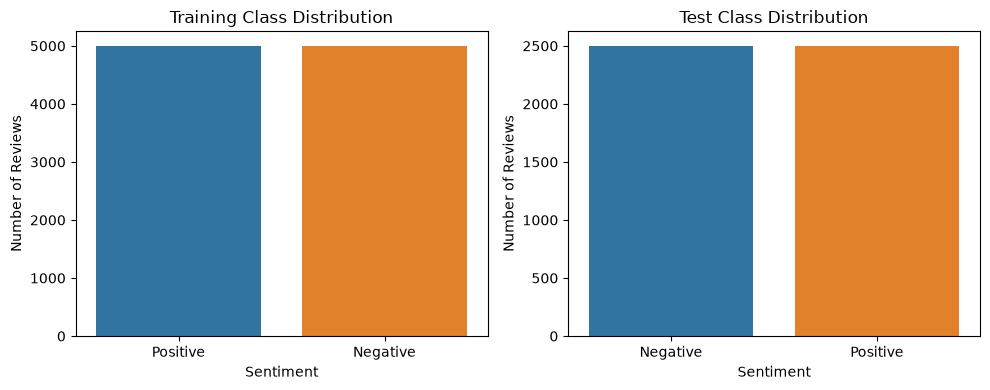

In [3]:
dataset_summary = pd.DataFrame({
    "train": [len(train_df), train_df["text"].isna().sum(),
              train_df["text"].duplicated().sum(),
              (train_df["label"] == 0).sum(), (train_df["label"] == 1).sum()],
    "test": [len(test_df), test_df["text"].isna().sum(),
             test_df["text"].duplicated().sum(),
             (test_df["label"] == 0).sum(), (test_df["label"] == 1).sum()],
}, index=["Rows", "Missing text", "Duplicate text",
          "Negative reviews", "Positive reviews"])
display(dataset_summary)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.countplot(data=train_df, x="sentiment", hue="sentiment", legend=False, ax=axes[0])
sns.countplot(data=test_df, x="sentiment", hue="sentiment", legend=False, ax=axes[1])
axes[0].set_title("Training Class Distribution")
axes[1].set_title("Test Class Distribution")
for axis in axes:
    axis.set_xlabel("Sentiment")
    axis.set_ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

<h3 style="color:#009E73;">Dataset Quality and Class Balance</h3>

The selected data contains no missing text. The training sample contains exactly `5,000` negative and `5,000` positive reviews, while the test sample contains `2,500` reviews from each class. The plots confirm that both splits are perfectly balanced.

The inspection found `18` duplicated reviews inside the training sample and `8` inside the test sample. This is a small fraction of the data, but it is now documented. Before model evaluation on Day 2, duplicates and any possible train-test overlap should be checked so repeated text cannot make the final result overly optimistic.

<h2 style="color:#0072B2;">1.3 Why Text Needs Preprocessing</h2>

A model cannot read raw text; it needs numerical input. Before numerical representation, text should be cleaned and standardized.

Without normalization:

$$
\text{Good} \neq \text{good} \neq \text{good!}
$$

Raw IMDB reviews may contain HTML tags, capitalization differences, punctuation, numbers, repeated spaces, common low-signal words, and negation contractions.

The goal is not to delete as much text as possible. It is to reduce unnecessary variation while preserving the information that determines sentiment.

In [4]:
example_indices = [
    train_df.index[train_df["label"] == 0][0],
    train_df.index[train_df["label"] == 1][0],
]
for number, index in enumerate(example_indices, start=1):
    print(f"--- Raw Example {number}: {train_df.loc[index, 'sentiment']} ---")
    print(train_df.loc[index, "text"][:900])
    print()

--- Raw Example 1: Negative ---
I went to see this movie with my 17 y.o. daughter. I insisted we go the matinée showing, not because I'm a tightwad, but just feeling I had. In the NASCAR spirit, this is a sponser's dream. SO much blatant advertising, it almost qualifies as an info-mercial, if it weren't for the so-called acting. Keeping with tradition, the Herbie franchise continues with its cheesy story lines, the car is only a 'vehicle' (no pun intended)for this cornball of a motion picture. Earlier Herbie installments (although cheesy as well) were produced during more serious times, making them a little easier to digest. Ms. Lohan, Disney's reigning drama queen, has little acting ability. I was surprised that Mr. Keaton and Mr. Dillon would get involved in such a project. Only the snack bar, was a bigger ripoff!

--- Raw Example 2: Positive ---
This is a true "80's movie": Back then they made maybe 100 times more movies than nowadays, and that makes many of them quite interesting..

<h3 style="color:#D55E00;">Observed Raw-Text Problems</h3>

The displayed reviews should be checked for HTML tags, punctuation, capitalization, numbers, repeated spacing, and negation.

These elements are not equally harmful. Punctuation may be removed for a TF-IDF baseline, but negation must remain because it can reverse the meaning of the following word.

<h2 style="color:#0072B2;">1.4 Tokenization: Words and Sub-words</h2>

Tokenization splits text into smaller units called tokens.

### Word Tokenization

A word tokenizer converts `The movie was great!` into separate words and punctuation. This representation is suitable for the classical TF-IDF pipeline used on Day 2.

### Sub-word Tokenization

Modern transformers divide uncommon words into known pieces. Conceptually:

$$
\text{unbelievable} \rightarrow [\text{un, believe, able}]
$$

This allows the model to process words that are not stored as complete vocabulary entries. A pretrained transformer's own tokenizer should be used with that transformer; our NLTK tokenizer is intended for today's classical text pipeline.

In [5]:
tokenization_example = (
    "The movie was not great, but the acting was unbelievable!"
)
word_tokens = word_tokenize(tokenization_example)

print("Original text:")
print(tokenization_example)
print("\nWord tokens:")
print(word_tokens)
print("\nNumber of tokens:", len(word_tokens))

Original text:
The movie was not great, but the acting was unbelievable!

Word tokens:
['The', 'movie', 'was', 'not', 'great', ',', 'but', 'the', 'acting', 'was', 'unbelievable', '!']

Number of tokens: 12


<h3 style="color:#009E73;">Tokenization Interpretation</h3>

The tokenizer divided the example into `12` tokens, treating the comma and exclamation mark as separate units. Stop-word removal and lemmatization can now operate on individual tokens.

The word `not` remained visible as its own token. This preserves the difference between `great` and `not great`.

<h2 style="color:#0072B2;">1.5 Cleaning and Normalization</h2>

| Step | What It Does | Example |
|---|---|---|
| HTML removal | Removes formatting tags | `<br />great` → `great` |
| Lowercasing | Removes case differences | `Good` → `good` |
| Negation expansion | Preserves contracted negation | `wasn't` → `was not` |
| Punctuation/numbers removal | Removes non-word noise | `great!` → `great` |
| Stop-word removal | Drops common low-signal words | removes `the`, `is`, `a` |
| Lemmatization | Reduces words to a base form | `running`, `ran` → `run` |

Negation must be expanded before punctuation removal. Otherwise, `wasn't` may become `wasn t`, and its negative meaning will be lost.

In [6]:
cleaning_example = "This Movie wasn't GOOD!!! <br /> I rated it 3/10."

without_html = re.sub(r"<[^>]+>", " ", html.unescape(cleaning_example))
lowercase_text = without_html.lower()
expanded_text = re.sub(r"\bwon['’]t\b", "will not", lowercase_text)
expanded_text = re.sub(r"\bcan['’]t\b", "can not", expanded_text)
expanded_text = re.sub(r"n['’]t\b", " not", expanded_text)
letters_only = re.sub(r"[^a-z\s]", " ", expanded_text)
normalized_text = re.sub(r"\s+", " ", letters_only).strip()

cleaning_steps = pd.DataFrame({
    "stage": ["Raw text", "HTML removed", "Lowercased",
              "Negation expanded", "Punctuation/numbers removed"],
    "text": [cleaning_example, without_html, lowercase_text,
             expanded_text, normalized_text],
})
display(cleaning_steps)

,stage,text
0,Raw text,This Movie wasn't GOOD!!! <br /> I rated it 3/10.
1,HTML removed,This Movie wasn't GOOD!!! I rated it 3/10.
2,Lowercased,this movie wasn't good!!! i rated it 3/10.
3,Negation expanded,this movie was not good!!! i rated it 3/10.
4,Punctuation/numbers removed,this movie was not good i rated it


<h3 style="color:#009E73;">Cleaning Result</h3>

The table confirms that the HTML tag was removed, uppercase `GOOD` became `good`, and punctuation and the numerical rating were removed.

Most importantly, `wasn't` became `was not` before the apostrophe disappeared. The final normalized sentence therefore kept its negative sentiment signal.

<h2 style="color:#0072B2;">1.6 Stop-word Removal</h2>

Stop words are common words that often carry little classification information, such as `the`, `is`, and `a`. Removing them can reduce vocabulary size.

However, preprocessing is task-dependent. Standard lists may include negation words, although:

$$
\text{good} \neq \text{not good}
$$

Therefore, we remove common stop words but preserve `not`, `no`, and `nor`.

In [7]:
NEGATION_WORDS = {"not", "no", "nor"}
default_stop_words = set(stopwords.words("english"))
task_stop_words = default_stop_words - NEGATION_WORDS

stopword_example = "the movie is not a good movie"
stopword_tokens = word_tokenize(stopword_example)
filtered_tokens = [token for token in stopword_tokens
                   if token not in task_stop_words]

print("Default list contains 'not':", "not" in default_stop_words)
print("Task list contains 'not':", "not" in task_stop_words)
print("Original tokens:", stopword_tokens)
print("Filtered tokens:", filtered_tokens)
assert "not" in filtered_tokens
print("Negation-preservation check passed.")

Default list contains 'not': True
Task list contains 'not': False
Original tokens: ['the', 'movie', 'is', 'not', 'a', 'good', 'movie']
Filtered tokens: ['movie', 'not', 'good', 'movie']
Negation-preservation check passed.


<h3 style="color:#009E73;">Task-Dependent Stop-word Decision</h3>

The output confirms that the default NLTK list contains `not`, while the customized task list does not remove it. The words `the`, `is`, and `a` disappeared, while `movie not good movie` remained.

This demonstrates why a standard preprocessing list should not be accepted blindly. A word that is unimportant for one task may be essential for another.

<h2 style="color:#0072B2;">1.7 Lemmatization vs. Stemming</h2>

Stemming removes word endings with simple rules. It is fast, but it may produce forms that are not real words.

Lemmatization returns a dictionary base form called a lemma. It can use the word's grammatical role to preserve meaning more accurately.

$$
\text{running} \rightarrow \text{run}
$$

This notebook selects POS-aware lemmatization because the objective is to reduce vocabulary while preserving meaningful words.

In [8]:
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

word_examples = [
    ("studies", wordnet.VERB), ("studying", wordnet.VERB),
    ("running", wordnet.VERB), ("better", wordnet.ADJ),
    ("movies", wordnet.NOUN),
]
morphology_comparison = pd.DataFrame({
    "word": [word for word, _ in word_examples],
    "stemming": [stemmer.stem(word) for word, _ in word_examples],
    "lemmatization": [lemmatizer.lemmatize(word, pos)
                        for word, pos in word_examples],
})
display(morphology_comparison)

,word,stemming,lemmatization
0,studies,studi,study
1,studying,studi,study
2,running,run,run
3,better,better,good
4,movies,movi,movie


<h3 style="color:#009E73;">Stemming and Lemmatization Interpretation</h3>

The results show that stemming reduced `studies` and `studying` to the non-dictionary form `studi`, and reduced `movies` to `movi`. Lemmatization produced the valid forms `study` and `movie`.

With grammatical information, `running` became `run` and the adjective `better` became `good`. Lemmatization is therefore the more interpretable choice for the final pipeline.

<h2 style="color:#0072B2;">1.8 Complete Text-Cleaning Pipeline</h2>

The complete order is:

$$
\text{Raw text} \rightarrow \text{HTML removal} \rightarrow \text{Lowercasing}
\rightarrow \text{Negation expansion} \rightarrow \text{Punctuation removal}
\rightarrow \text{Tokenization} \rightarrow \text{Stop-word removal}
\rightarrow \text{Lemmatization}
$$

The order matters. Negation is expanded before punctuation removal, and stop words are removed before the more expensive POS-tagging step.

The same function should later process new reviews so training-time and prediction-time inputs remain consistent.

In [9]:
def expand_negations(text):
    text = re.sub(r"\bwon['’]t\b", "will not", text)
    text = re.sub(r"\bcan['’]t\b", "can not", text)
    return re.sub(r"n['’]t\b", " not", text)


def to_wordnet_pos(treebank_tag):
    tag_map = {"J": wordnet.ADJ, "N": wordnet.NOUN,
               "V": wordnet.VERB, "R": wordnet.ADV}
    return tag_map.get(treebank_tag[0].upper(), wordnet.NOUN)


def preprocess_text(text):
    text = html.unescape(str(text))
    text = re.sub(r"<[^>]+>", " ", text)
    text = expand_negations(text.lower())
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    tokens = word_tokenize(text)
    tokens = [token for token in tokens
              if token not in task_stop_words and len(token) > 1]
    tagged_tokens = nltk.pos_tag(tokens)
    lemmas = [lemmatizer.lemmatize(token, to_wordnet_pos(tag))
              for token, tag in tagged_tokens]
    return " ".join(lemmas)

In [10]:
pipeline_tests = pd.DataFrame({
    "raw_text": [
        "The movie was not good.",
        "The movie wasn't good!",
        "RUNNING actors were better in earlier movies.",
        "<br /> An AMAZING movie — I loved it!!!",
    ]
})
pipeline_tests["cleaned_text"] = pipeline_tests["raw_text"].apply(preprocess_text)
display(pipeline_tests)

assert "not" in pipeline_tests.loc[0, "cleaned_text"].split()
assert "not" in pipeline_tests.loc[1, "cleaned_text"].split()
assert "<br" not in pipeline_tests.loc[3, "cleaned_text"]
print("All pipeline tests passed.")

,raw_text,cleaned_text
0,The movie was not good.,movie not good
1,The movie wasn't good!,movie not good
2,RUNNING actors were better in earlier movies.,run actor well early movie
3,<br /> An AMAZING movie — I loved it!!!,amazing movie love


All pipeline tests passed.


<h3 style="color:#009E73;">Pipeline Verification</h3>

All pipeline tests passed. Both `not` and the contraction `wasn't` produced the cleaned phrase `movie not good`. The third example was reduced to `run actor well early movie`, and the HTML example became `amazing movie love`.

These results verify that explicit and contracted negation survived, lemmatization was applied, and HTML, punctuation, and capitalization differences were removed.

<h2 style="color:#0072B2;">1.9 Applying the Pipeline to IMDB</h2>

The verified function is applied to the selected training and test reviews. POS tagging and lemmatization inspect every token, so this step may require several minutes on a CPU.

The raw `text` column is preserved so that every cleaning decision can be inspected later.

In [11]:
tqdm.pandas(desc="Cleaning training reviews")
train_df["cleaned_text"] = train_df["text"].progress_apply(preprocess_text)

tqdm.pandas(desc="Cleaning test reviews")
test_df["cleaned_text"] = test_df["text"].progress_apply(preprocess_text)

print("Training reviews processed:", len(train_df))
print("Test reviews processed:", len(test_df))

Cleaning training reviews:   0%|          | 0/10000 [00:00<?, ?it/s]

Cleaning test reviews:   0%|          | 0/5000 [00:00<?, ?it/s]

Training reviews processed: 10000
Test reviews processed: 5000


<h2 style="color:#0072B2;">1.10 Preprocessing Quality Checks</h2>

The checks answer four questions:

1. Did preprocessing produce missing values?
2. Did any review become empty?
3. Did the average review length decrease?
4. Are negation words still present?

A large reduction is useful only if the task-critical meaning remains.

In [12]:
train_df["raw_word_count"] = train_df["text"].str.split().str.len()
train_df["clean_word_count"] = train_df["cleaned_text"].str.split().str.len()

quality_summary = pd.Series({
    "Training rows": len(train_df),
    "Missing cleaned reviews": train_df["cleaned_text"].isna().sum(),
    "Empty cleaned reviews": train_df["cleaned_text"].str.strip().eq("").sum(),
    "Average raw words": train_df["raw_word_count"].mean(),
    "Average cleaned words": train_df["clean_word_count"].mean(),
    "Reviews containing 'not'": train_df["cleaned_text"].str.contains(
        r"\bnot\b", regex=True).sum(),
})
display(quality_summary.to_frame("value"))
assert quality_summary["Missing cleaned reviews"] == 0
assert quality_summary["Empty cleaned reviews"] == 0

,value
Training rows,10000.0000
Missing cleaned reviews,0.0000
Empty cleaned reviews,0.0000
Average raw words,232.1981
Average cleaned words,121.5624
Reviews containing 'not',8266.0000


,sentiment,text,cleaned_text
6252,Positive,"After losing his cattle herd to a dishonest lawman, a trail boss winds up in the Yukon gold fields with a bad reputation and small chances of being able to return to the states. While there his fortunes take a turn for the best until a bad luck specter from the past comes calling. Good western with many favorite old faces in the lineup.",lose cattle herd dishonest lawman trail bos wind yukon gold field bad reputation small chance able return state fortune take turn best bad luck specter past come call good western many favorite old face lineup
4684,Positive,"I can remember this movie from when i was a small child, i loved it then and I still do now. I managed to get it on DVD for my 18th Birthday and was over joyed because I had found it so difficult to find it previously and it had only be rented when i was younger. My favourite character is Charlie because he learns to be a good dog. The movie is...",remember movie small child love still manage get dvd th birthday joy find difficult find previously rent young favourite character charlie learn good dog movie fill fun song music animation brilliant character voice perfect movie always tearjerker think not see movie small would not find brilliant fascinating although still believe would still ...
1731,Negative,"""Show me your boobies!"" is not funny, and certainly not on a channel that shows cartoons if you understand where I'm coming from. I don't want my 6 and 7 years old daughters thinking like that or hearing that. I find it sad that Nick hyped this crap THAT much and then that's what we get, stupid little kids acting like stupid adults. I know it's...",show boobies not funny certainly not channel show cartoon understand come not want year old daughter think like hear find sad nick hype crap much get stupid little kid act like stupid adult know meant humorous consider sweet little innocent girl st grade not wait see comment disappoint saw daughter not watch love block nick not heart point nick...
4742,Positive,"I remember Casper comic books, but don't remember any cartoons. Maybe they weren't memorable; I don't know but at my advanced age, here I am watching this very early Casper animated short yesterday. Afterward, I was shocked to read the user-comments here. Did people miss the ending?<br /><br />I have to learn all over again that Casper isn't li...",remember casper comic book not remember cartoon maybe not memorable not know advanced age watch early casper animate short yesterday afterward shock read user comment people miss end learn casper not like ghost like go night scare everyone see no future accord narrator instead one night go rural section town inadvertently scar animal not find f...


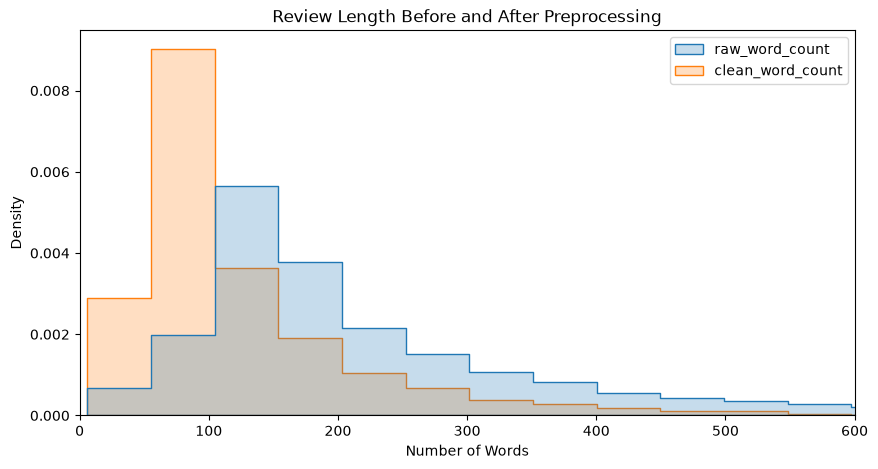

In [13]:
comparison_sample = train_df.sample(4, random_state=SEED)[
    ["sentiment", "text", "cleaned_text"]
]
pd.set_option("display.max_colwidth", 350)
display(comparison_sample)

plt.figure(figsize=(10, 5))
sns.histplot(train_df[["raw_word_count", "clean_word_count"]],
             bins=50, element="step", stat="density", common_norm=False)
plt.xlim(0, 600)
plt.title("Review Length Before and After Preprocessing")
plt.xlabel("Number of Words")
plt.ylabel("Density")
plt.show()

<h3 style="color:#009E73;">Preprocessing Interpretation</h3>

The complete pipeline processed all `10,000` training reviews and `5,000` test reviews. It produced zero missing and zero empty cleaned reviews.

The average training-review length decreased from `232.20` to `121.56` words, a reduction of approximately `47.65%`. This shows that the pipeline removed a large amount of low-signal text without deleting entire reviews.

The word `not` remained in `8,266` cleaned training reviews, confirming that task-critical negation was preserved. The before-and-after samples also show that the main sentiment words remain readable.

In [14]:
vocabulary_sample = train_df.head(1000)
raw_tokens = re.findall(r"[a-z]+", " ".join(vocabulary_sample["text"]).lower())
clean_tokens = " ".join(vocabulary_sample["cleaned_text"]).split()

vocabulary_summary = pd.DataFrame({
    "stage": ["Raw text", "Cleaned text"],
    "total_tokens": [len(raw_tokens), len(clean_tokens)],
    "unique_tokens": [len(set(raw_tokens)), len(set(clean_tokens))],
})
display(vocabulary_summary)
display(pd.DataFrame(Counter(clean_tokens).most_common(15),
                     columns=["word", "count"]))

,stage,total_tokens,unique_tokens
0,Raw text,239839,17729
1,Cleaned text,121693,14610


,word,count
0,not,2630
1,movie,2094
2,film,1912
3,one,1093
4,make,926
5,like,873
6,see,807
7,get,706
8,good,689
9,time,657


<h3 style="color:#009E73;">Vocabulary Reduction</h3>

Across the inspected `1,000` reviews, preprocessing reduced the total token count from `239,839` to `121,693`, a reduction of approximately `49.26%`. The number of unique tokens decreased from `17,729` to `14,610`, a reduction of approximately `17.59%`.

This produces a smaller and more consistent vocabulary for TF-IDF. The most frequent cleaned terms include `movie`, `film`, `good`, `character`, `watch`, and `story`, which are relevant to movie-review content. `not` is the most frequent retained token because it was deliberately protected from stop-word removal.

<h2 style="color:#0072B2;">1.11 Saving the Day 1 Output</h2>

The cleaned training and test data are saved separately. Each output contains the raw text, cleaned text, numerical label, and readable sentiment.

Day 2 will fit TF-IDF only on `imdb_train_cleaned.csv` and transform `imdb_test_cleaned.csv` using the fitted vectorizer.

In [15]:
output_directory = Path("outputs/week8_day1")
output_directory.mkdir(parents=True, exist_ok=True)
output_columns = ["text", "cleaned_text", "label", "sentiment"]

train_output_path = output_directory / "imdb_train_cleaned.csv"
test_output_path = output_directory / "imdb_test_cleaned.csv"
train_df[output_columns].to_csv(train_output_path, index=False)
test_df[output_columns].to_csv(test_output_path, index=False)

print("Saved training data to:", train_output_path)
print("Saved test data to:", test_output_path)
print("Saved training rows:", len(train_df))
print("Saved test rows:", len(test_df))

Saved training data to: outputs/week8_day1/imdb_train_cleaned.csv
Saved test data to: outputs/week8_day1/imdb_test_cleaned.csv
Saved training rows: 10000
Saved test rows: 5000


<h2 style="color:#0072B2;">Day 1 Conclusion</h2>

This notebook completed the Day 1 requirements for Sprint 3.

### Sprint Planning

The Sprint 3 goal and the integration and evaluation backlog were defined. Today's reusable preprocessing component is the first backlog result.

### Text Preprocessing

IMDB reviews were tokenized and cleaned using HTML removal, lowercasing, negation expansion, punctuation removal, task-aware stop-word removal, and POS-aware lemmatization.

### Task-Critical Signal

The words `not`, `no`, and `nor` were preserved because negation can reverse sentiment. Assertions verified both explicit and contracted negation.

### Lemmatization Decision

Lemmatization was selected instead of stemming because it aims to preserve meaning and return dictionary base forms.

### Final Deliverables

The notebook processed `10,000` training reviews and `5,000` test reviews and produced no missing or empty cleaned text. Average review length decreased by approximately `47.65%`, while negation remained available for sentiment analysis. Separate cleaned training and test files were saved while retaining raw text for inspection.

The data-quality check also identified `18` duplicate training reviews and `8` duplicate test reviews. These counts are documented and should be handled together with a train-test overlap check before model evaluation on Day 2.

On Day 2, the cleaned data will be represented using TF-IDF and word embeddings and compared using a common classification task.

### Tools Used

NLTK • Hugging Face Datasets • Pandas • NumPy • Matplotlib • Seaborn • Jupyter/Colab • Git & GitHub